# LangGraph e2

## 1.  dependencies

In [2]:
%pip install -q langgraph langchain-ollama scikit-learn
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## 2. Imports

In [1]:
import re
import os
from typing import TypedDict, List

from langchain_ollama import ChatOllama
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START, END
from sklearn.feature_extraction.text import TfidfVectorizer

## 3. DEFINICION DE ESTADOS DEL GRAFICO

Ahora el estado compartido entre los dos agentes tiene tres campos:

- `input_text`: el texto original que entra al grafo.
- `key_terms`: los 5 términos más importantes según TF-IDF (los llena el **agente 1**).
- `questions`: las preguntas generadas (las llena el **agente 2**, usando `input_text` y `key_terms`).

In [2]:
class MultiAgentState(TypedDict, total=False):
    input_text: str
    key_terms: List[str]
    questions: List[str]
    answers: List[str]

## 4. Set up the local LLM


In [3]:
llm = ChatOllama(model="gemma4:e2b", temperature=0)

## 5. Agente 1: Analista de texto (tool TF-IDF)

Este agente no necesita el LLM: su trabajo es aplicar una **tool determinística** (TF-IDF) sobre el texto y extraer los términos más relevantes.


In [4]:
@tool
def tfidf_top_terms(text: str, top_n: int = 5) -> List[str]:
    """Return the top_n most important terms in `text` according to TF-IDF."""
    sentences = [s.strip() for s in re.split(r"(?<=[.!?])\s+", text) if s.strip()]
    if len(sentences) < 2:
        sentences = sentences + [text]

    vectorizer = TfidfVectorizer(stop_words="english")
    tfidf_matrix = vectorizer.fit_transform(sentences)

    scores = tfidf_matrix.sum(axis=0).A1
    terms = vectorizer.get_feature_names_out()

    ranked_terms = sorted(zip(terms, scores), key=lambda pair: pair[1], reverse=True)
    return [term for term, _ in ranked_terms[:top_n]]

def text_analyst(state: MultiAgentState) -> dict:
    top_terms = tfidf_top_terms.invoke({"text": state["input_text"], "top_n": 5})
    return {"key_terms": top_terms}

In [5]:
def load_prompt(file_path: str) -> str:
    with open(file_path, "r", encoding="utf-8") as file:
        return file.read()

## 6. Agente 2: Generador de preguntas

1. Lee `input_text` **y** `key_terms` (los 5 términos TF-IDF del agente 1) desde el estado.
2. Envía ambos al **LLM**, mediante un mensaje de sistema y uno de usuario, pidiendo preguntas **en inglés** enfocadas especialmente en esos términos.
3. Divide y limpia la respuesta para obtener una **lista de preguntas**.
4. Retorna `{"questions": [...]}`, que LangGraph integra nuevamente en el estado.

In [7]:
QUESTIONS_SYSTEM_PROMPT = load_prompt("/home/acha/Documentos/DocsObsi/Prompts/questions_system_prompt.md")
QUESTIONS_HUMAN_PROMPT = load_prompt("/home/acha/Documentos/DocsObsi/Prompts/questions_human_prompt.md")

questions_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", QUESTIONS_SYSTEM_PROMPT),
        ("human", QUESTIONS_HUMAN_PROMPT),
    ]
)

questions_chain = questions_prompt | llm

def generate_questions(state: MultiAgentState) -> dict:
    key_terms_str = ", ".join(state["key_terms"])

    response = questions_chain.invoke(
        {"input_text": state["input_text"], "key_terms": key_terms_str}
    )

    questions = [line.strip("-*0123456789. ").strip()
                 for line in response.content.splitlines()
                 if line.strip()]

    return {"questions": questions}

ANSWERS_SYSTEM_PROMPT = load_prompt("/home/acha/Documentos/DocsObsi/Prompts/answers_system_prompt.md")
ANSWERS_HUMAN_PROMPT = load_prompt("/home/acha/Documentos/DocsObsi/Prompts/answers_human_prompt.md")

answers_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", ANSWERS_SYSTEM_PROMPT),
        ("human", ANSWERS_HUMAN_PROMPT),
    ]
)

answers_chain = answers_prompt | llm

def answer_questions(state: MultiAgentState) -> dict:
    questions_str = "\n".join(
        [f"- {q}" for q in state["questions"]]
    )

    response = answers_chain.invoke(
        {"input_text": state["input_text"], "questions": questions_str}
    )

    answers = [
        line.strip("-*0123456789. ").strip()
        for line in response.content.splitlines()
        if line.strip()
    ]

    return {"answers": answers}

## 7. Construir el grafo

Registramos los dos nodos y encadenamos los bordes: `START -> text_analyst -> generate_questions -> END`.

In [8]:
graph_builder = StateGraph(MultiAgentState)

graph_builder.add_node("text_analyst", text_analyst)
graph_builder.add_node("generate_questions", generate_questions)
graph_builder.add_node("answer_questions", answer_questions)

graph_builder.add_edge(START, "text_analyst")
graph_builder.add_edge("text_analyst", "generate_questions")
graph_builder.add_edge("generate_questions", "answer_questions")
graph_builder.add_edge("answer_questions", END)

graph = graph_builder.compile()

### Visualize the graph



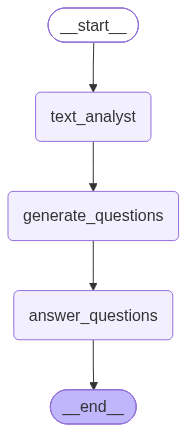

In [9]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Graph visualization needs graphviz/mermaid extras, skipping:", e)

In [10]:
sample_text = (
"""
 Hola, ¿cómo están? Este es un mini video para solucionar
 un descuido que tuve en el video anterior y que ustedes han 
 corregido en los comentarios.
   Si tienen razón, olvidé decorar la última función. 
   Recuerden que habíamos creado una función llamada Power y me concentré
     en explicar los argumentos con clave-valor. Y olvidé por completo decorarla.
       Es necesario decorar la función Power. 
       Incluir la nomenclatura de la función decorada es importante.
         De esta manera, se le indica que es una función decorada.
           Una vez hecho esto, guardamos los cambios y ejecutamos el programa.
 Y ahora sí, no me había dado cuenta de que antes del valor, 
la decoración de la función o la impresión que pusimos antes o la impresión 
que pusimos después, pero ahora está resuelto. Bien, son cosas directas. 
Gracias a todos por su atención. No se preocupen, nos vemos en el próximo video.
"""
)

result = graph.invoke({"input_text": sample_text})

print("Top TF-IDF terms:")
print(", ".join(result["key_terms"]))

print("\nGenerated Questions & Answers (English):\n")
for i, (q, a) in enumerate(
    zip(result["questions"], result.get("answers", [])), start=1
):
    print(f"{i}. Q: {q}")
    print(f"   A: {a}\n")

Top TF-IDF terms:
la, función, que, es, en

Generated Questions & Answers (English):

1. Q: What is the function decorated?
   A: What is the function decorated?

2. Q: How is the function decorated?
   A: The function called Power

3. Q: Where is decoration included?
   A: How is the function decorated?

